# 📊 Phase 1: Data Exploration & Preprocessing Analysis

This notebook provides visual and statistical exploration of the raw preprocessed multilingual dataset (`global_data.csv`) extracted from the MySQL database.

### 📁 Architecture Role:
- **Phase 1 (`data_exploration/`)**: Article extraction from SQL (`fetch_and_preprocess_sql.py`) ➔ Language filtering & preprocessing (`global_data.csv`) ➔ Visual Exploration & Quality Control (`data_exploration.ipynb`).
- **Phase 2 (`data_libelisation/`)**: Interactive Arabic human labeling (`cli_annotator.py`) ➔ Output labeled dataset (`global_data_libelised.csv`) + Libellisation plots (`data_libelisation/plots/`).

### 🌐 Supported Languages:
- **Arabic (`ar`)**, **English (`en`)**, **French (`fr`)**

### 📄 Target Dataset Schema:
- `id`: Unique article identifier
- `text`: Cleaned article text
- `language`: Detected language (`ar`, `en`, `fr`)

In [1]:
# 1. Environment & Visualization Setup
import os
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configure plotting styles
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

# Standardized Colour Palettes
LANG_COLORS = {
    "ar":       "#2E86AB",
    "en":       "#A23B72",
    "fr":       "#F18F01",
    "Arabic":   "#2E86AB",
    "English":  "#A23B72",
    "French":   "#F18F01",
    "Mixed":    "#C73E1D",
    "Rejected": "#8B8B8B",
}

REJECT_COLORS = {
    "Too short":      "#E63946",
    "Low confidence": "#457B9D",
    "Low quality":    "#A8DADC",
    "Unsupported":    "#F4A261",
}

# Output directory for exported figures
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def fmt_k(n: int) -> str:
    if n >= 1_000_000:
        return f"{n/1e6:.1f}M"
    if n >= 1_000:
        return f"{n/1e3:.1f}K"
    return str(n)

print("✓ Visualization environment initialized.")

✓ Visualization environment initialized.


## 2. Load Dataset (`global_data.csv`)

In [2]:
# Locate global_data.csv
candidates = [
    Path("global_data.csv"),
    Path("../data_exploration/global_data.csv"),
    Path("data_exploration/global_data.csv"),
]

DATA_PATH = None
for c in candidates:
    if c.exists():
        DATA_PATH = c.resolve()
        break

if not DATA_PATH:
    raise FileNotFoundError("global_data.csv not found! Run fetch_and_preprocess_sql.py first.")

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"Total Articles : {len(df):,}")
print(f"Schema Columns : {list(df.columns)}")
print(f"Memory Usage   : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
df.head(5)

Loading dataset from: C:\Users\bello\Desktop\Data_Exploring\data_exploration\global_data.csv
Total Articles : 1,569,556
Schema Columns : ['id', 'text', 'language']
Memory Usage   : 675.09 MB


,id,text,language
0,208011,لقد قالها الزعيم القذافي من منبر إذاعة سرت في ...,ar
1,208012,سيحيا الوطن عندما يفني كل طحلوب في كل انحاء ليبيا,ar
2,208013,(حقيقة) أجمل ما في عار قهاير . في ناس كانت في ...,ar
3,208015,السلام عليكم يااحرار العضميي يا احباب ابو منيار,ar
4,208016,مشاركاتكم .مبروك عليكم كرازي ليبيا يا ليبين وم...,ar


## 3. Language Distribution Analysis (`ar`, `en`, `fr`)
Visualizing the language breakdown across the corpus.

            Count  Percentage (%)
language                         
ar        1383663           88.16
en         185082           11.79
fr            811            0.05


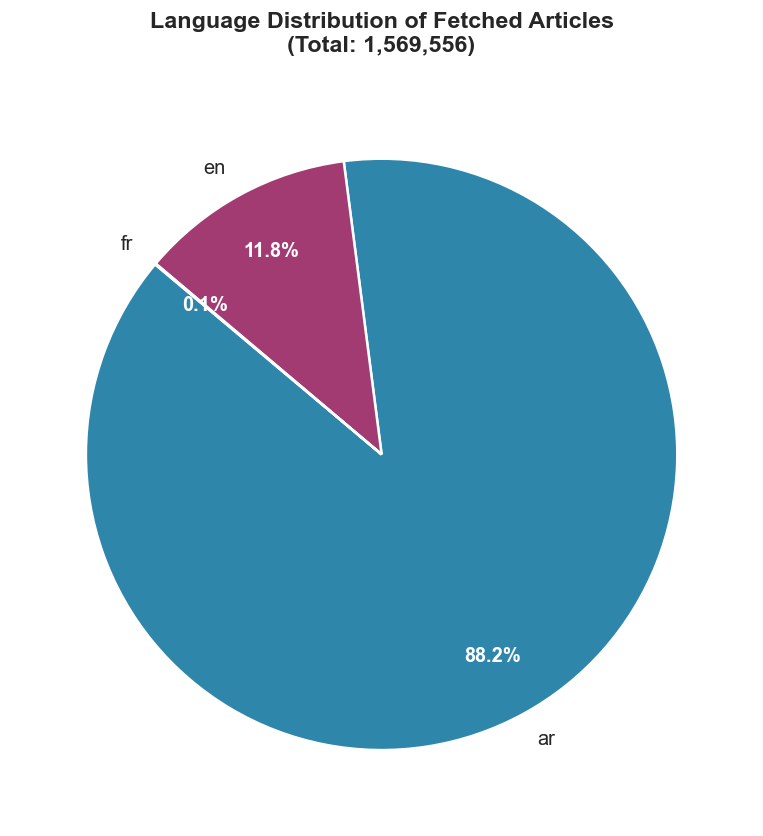

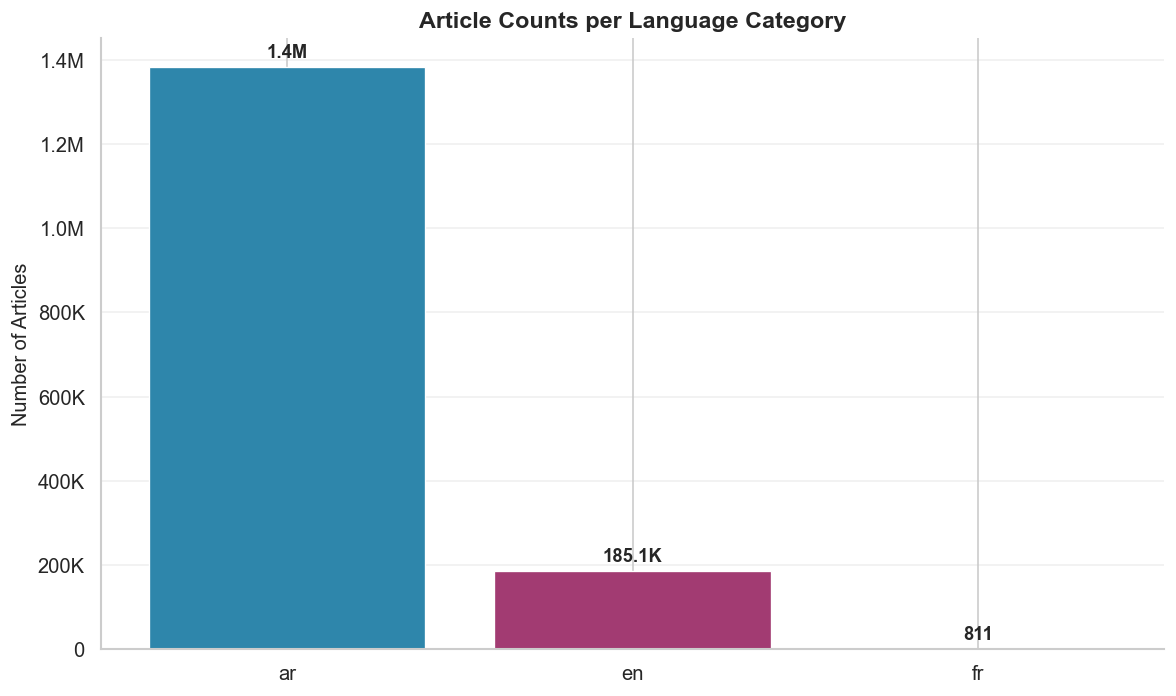

In [3]:
lang_counts = df["language"].value_counts()
lang_pct = df["language"].value_counts(normalize=True) * 100

lang_summary = pd.DataFrame({
    "Count": lang_counts,
    "Percentage (%)": lang_pct.round(2)
})
print(lang_summary)

colors = [LANG_COLORS.get(l, "#8B8B8B") for l in lang_counts.index]

# ── DIAGRAM 1: Language Distribution (Pie) ──
fig_lang_pie, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    lang_counts.values, labels=lang_counts.index, autopct="%1.1f%%",
    colors=colors, startangle=140,
    textprops={"fontsize": 12},
    pctdistance=0.78,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for t in autotexts:
    t.set_fontweight("bold")
    t.set_color("white")
ax.set_title(
    f"Language Distribution of Fetched Articles\n(Total: {len(df):,})",
    fontsize=14, fontweight="bold", pad=20,
)
plt.show()

# ── DIAGRAM 2: Language Distribution (Bar) ──
fig_lang_bar, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(lang_counts.index, lang_counts.values, color=colors, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, lang_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + len(df) * 0.008,
        f"{fmt_k(v)}", ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_ylabel("Number of Articles", fontsize=12)
ax.set_title("Article Counts per Language Category", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig_lang_bar.tight_layout()
plt.show()

## 4. Text Length & Corpus Size Analysis
Measuring word counts, character counts, and volume per language.

--- Overall Word Count Statistics ---
         word_count    char_count
count  1.569556e+06  1.569556e+06
mean   4.297391e+01  2.487569e+02
std    1.048509e+02  6.103393e+02
min    3.000000e+00  5.000000e+00
25%    1.100000e+01  6.400000e+01
50%    1.800000e+01  1.020000e+02
75%    2.800000e+01  1.600000e+02
90%    9.800000e+01  5.750000e+02
95%    1.670000e+02  9.830000e+02
99%    4.320000e+02  2.512000e+03
max    6.738000e+03  4.391000e+04

--- Word Count Statistics by Language ---
            count  mean  median    std  min   max
language                                         
ar        1383663  44.2    18.0  105.7    3  6738
en         185082  33.9    18.0   97.7    3  6571
fr            811  25.4    15.0   82.6    3  1620


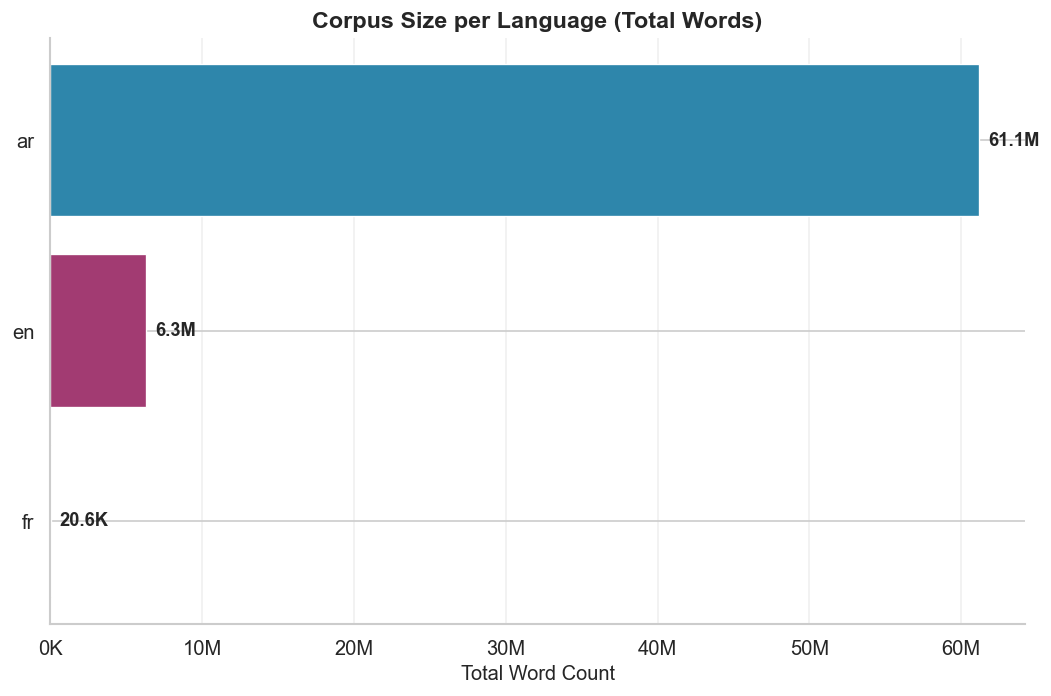

C:\Users\bello\AppData\Local\Temp\ipykernel_18876\3104434088.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


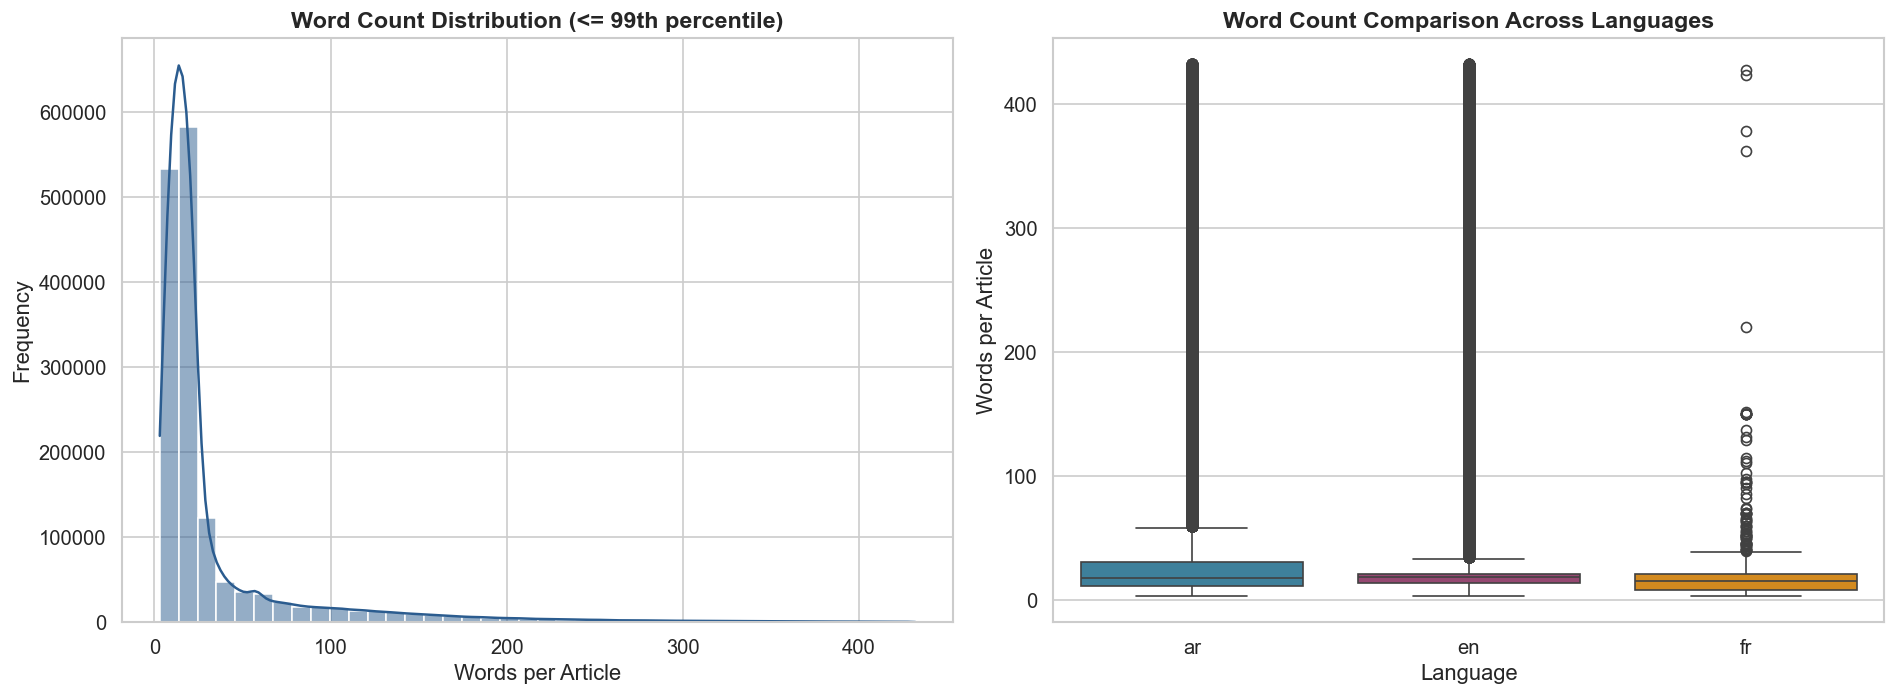

In [4]:
# Compute text statistics
df["char_count"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().apply(len)

print("--- Overall Word Count Statistics ---")
print(df[["word_count", "char_count"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\n--- Word Count Statistics by Language ---")
print(df.groupby("language")["word_count"].agg(["count", "mean", "median", "std", "min", "max"]).round(1))

# ── DIAGRAM 3: Corpus Size per Language (Total Words) ──
word_totals = df.groupby("language")["word_count"].sum()
wt_colors = [LANG_COLORS.get(l, "#8B8B8B") for l in word_totals.index]

fig_word_counts, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(word_totals.index, word_totals.values, color=wt_colors, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, word_totals.values):
    ax.text(
        bar.get_width() + max(word_totals.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        fmt_k(v), va="center", fontsize=11, fontweight="bold",
    )
ax.set_xlabel("Total Word Count", fontsize=12)
ax.set_title("Corpus Size per Language (Total Words)", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
fig_word_counts.tight_layout()
plt.show()

# ── DIAGRAM 4: Word Count Distribution (Histogram & Boxplot) ──
p99 = df["word_count"].quantile(0.99)
fig_wc_hist, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    df[df["word_count"] <= p99]["word_count"],
    kde=True, ax=axes[0], color="#2b5c8f", bins=40,
)
axes[0].set_title("Word Count Distribution (<= 99th percentile)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Words per Article")
axes[0].set_ylabel("Frequency")

sns.boxplot(
    data=df[df["word_count"] <= p99],
    x="language", y="word_count", ax=axes[1], palette=LANG_COLORS,
)
axes[1].set_title("Word Count Comparison Across Languages", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Language")
axes[1].set_ylabel("Words per Article")

plt.tight_layout()
plt.show()

## 5. Preprocessing & Extraction Quality Metrics
Parsing and displaying extraction / rejection statistics from `processing_stats.txt`.

Reading extraction stats from: processing_stats.txt


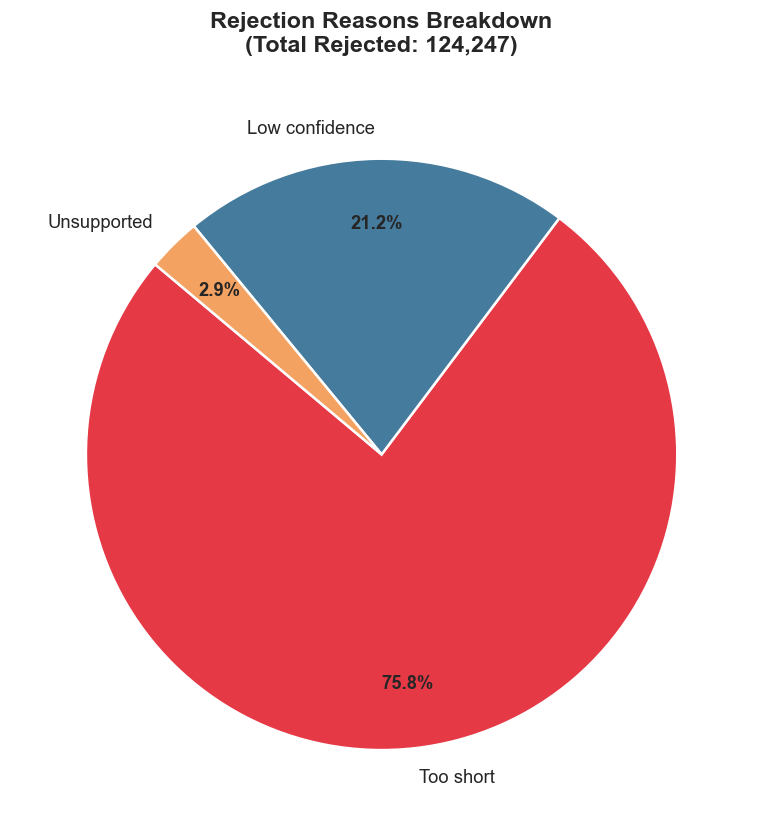

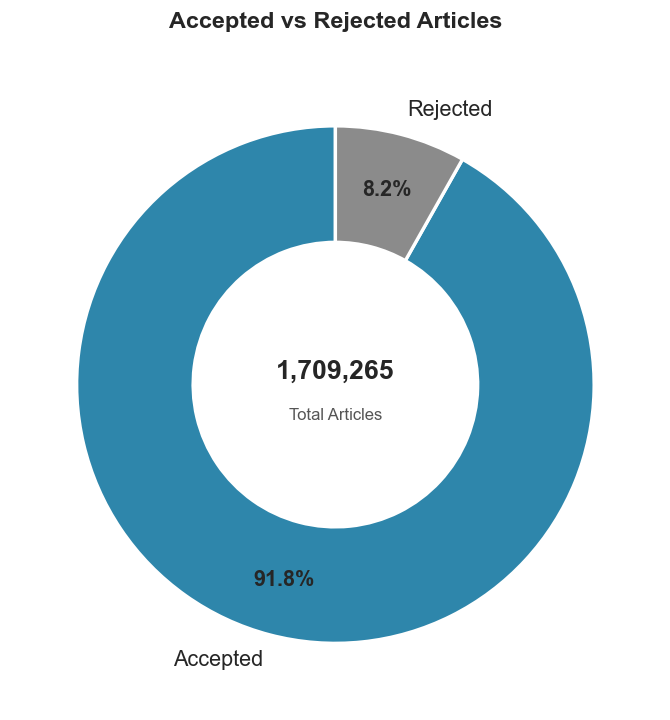

In [5]:
# Load or parse processing_stats.txt if available
stats_candidates = [
    Path("processing_stats.txt"),
    Path("../processing_stats.txt"),
    Path("../data_exploration/processing_stats.txt"),
]

stats_path = None
for c in stats_candidates:
    if c.exists():
        stats_path = c
        break

fig_rejection = None
fig_accepted_rejected = None

if stats_path:
    print(f"Reading extraction stats from: {stats_path}")
    text = stats_path.read_text(encoding="utf-8")
    
    def _grab(pattern: str) -> int:
        m = re.search(pattern, text)
        return int(m.group(1).replace(",", "").strip()) if m else 0
    
    total_fetched = _grab(r"Total\s*:\s*([\d,]+)\s*articles") or len(df)
    rejected = _grab(r"REJECTED\s+([\d,]+)")
    too_short = _grab(r"Too short.*?\s*:\s*([\d,]+)")
    low_conf = _grab(r"Low confidence.*?\s*:\s*([\d,]+)")
    low_qual = _grab(r"Low quality.*?\s*:\s*([\d,]+)")
    unsup = _grab(r"Unsupported language\s*:\s*([\d,]+)")
    
    # ── DIAGRAM 5: Rejection Reasons (Pie) ──
    reasons = {
        "Too short": too_short,
        "Low confidence": low_conf,
        "Low quality": low_qual,
        "Unsupported": unsup,
    }
    reasons = {k: v for k, v in reasons.items() if v > 0}
    
    if reasons:
        fig_rejection, ax = plt.subplots(figsize=(8, 8))
        wedges, texts, autotexts = ax.pie(
            list(reasons.values()), labels=list(reasons.keys()), autopct="%1.1f%%",
            colors=[REJECT_COLORS.get(k, "#8B8B8B") for k in reasons.keys()], startangle=140,
            textprops={"fontsize": 11}, pctdistance=0.78,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        )
        for t in autotexts: t.set_fontweight("bold")
        ax.set_title(f"Rejection Reasons Breakdown\n(Total Rejected: {sum(reasons.values()):,})", fontsize=14, fontweight="bold", pad=20)
        plt.show()
    
    # ── DIAGRAM 6: Accepted vs Rejected (Donut) ──
    accepted = len(df)
    fig_accepted_rejected, ax = plt.subplots(figsize=(7, 7))
    sizes = [accepted, rejected] if rejected > 0 else [accepted]
    labels = ["Accepted", "Rejected"] if rejected > 0 else ["Accepted"]
    colors_ar = ["#2E86AB", "#8B8B8B"] if rejected > 0 else ["#2E86AB"]
    
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, autopct="%1.1f%%", colors=colors_ar, startangle=90,
        pctdistance=0.78, wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 13},
    )
    for t in autotexts:
        t.set_fontweight("bold")
        t.set_fontsize(13)
    centre = plt.Circle((0, 0), 0.35, fc="white")
    ax.add_artist(centre)
    ax.text(0, 0.05, f"{total_fetched:,}", ha="center", va="center", fontsize=16, fontweight="bold")
    ax.text(0, -0.12, "Total Articles", ha="center", va="center", fontsize=10, color="#555")
    ax.set_title("Accepted vs Rejected Articles", fontsize=14, fontweight="bold", pad=20)
    plt.show()
else:
    print("ℹ processing_stats.txt not found. Run fetch_and_preprocess_sql.py to generate full quality stats.")

## 6. Sample Articles Inspection
Viewing cleaned natural text samples across languages.

In [6]:
print("=== Cleaned Natural Text Samples by Language ===\n")
for lang in df["language"].unique():
    sample_rows = df[df["language"] == lang].head(2)
    print(f"[Language: {str(lang).upper()}]")
    for _, r in sample_rows.iterrows():
        aid = r.get("id", "")
        txt = str(r.get("text", ""))[:180]
        print(f"  * ID {aid}: {txt}...")
    print()


=== Cleaned Natural Text Samples by Language ===

[Language: AR]
  * ID 208011: لقد قالها الزعيم القذافي من منبر إذاعة سرت في اخر خطاباته ان الليبيين سلكوا الطريق المعاكس والطريق الخطأ في الاصلاح والتغيير وقال ايضا ان الاستعمار يدفع الليبيين ليتقاتلوا بعضهم بب...
  * ID 208012: سيحيا الوطن عندما يفني كل طحلوب في كل انحاء ليبيا...

[Language: EN]
  * ID 208506: Politicians face death penalty over blasphemous cartoon Amnesty International .co/fWrkq 5 zu 0 X...
  * ID 208536: Democracy Fatigue in Libya، by .co/NbJkD 82 RFE...

[Language: FR]
  * ID 66202: salan yah ami...
  * ID 80476: org/portal/index .php/les-nouvelles/1463 Alors qu une certaine presse tente de vous vendre la présence du mouvement al-Qaïda dans le sud libyen، il s agit simplement de Libyens qui...



---
## 7. 💾 Export All Diagrams to `data_exploration/plots/`

Automatically saves all generated exploration charts and writes a `descriptions.txt` summary file.

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_REGISTRY = {
    "01_language_distribution_pie.png":     fig_lang_pie,
    "02_language_distribution_bar.png":     fig_lang_bar,
    "03_word_counts_per_language.png":      fig_word_counts,
    "04_word_count_distribution.png":       fig_wc_hist,
    "05_rejection_reasons_pie.png":         fig_rejection,
    "06_accepted_vs_rejected_donut.png":    fig_accepted_rejected,
}

saved_count = 0
for filename, fig in SAVE_REGISTRY.items():
    if fig is not None:
        path = OUTPUT_DIR / filename
        fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
        print(f"  ✓ saved {path.name}")
        saved_count += 1
    else:
        print(f"  ⊘ skipped {filename} (no data available)")

# Generate descriptions.txt
desc_lines = [
    "=" * 70,
    "  DATA EXPLORATION DIAGRAM DESCRIPTIONS",
    "  Auto-generated by data_exploration.ipynb",
    "=" * 70,
    "",
    "1. 01_language_distribution_pie.png: Proportional breakdown of articles across ar, en, fr.",
    "2. 02_language_distribution_bar.png: Absolute count of articles per language category.",
    "3. 03_word_counts_per_language.png: Total corpus word volume per language.",
    "4. 04_word_count_distribution.png: Article length histogram & cross-language boxplots.",
    "5. 05_rejection_reasons_pie.png: Reasons for discarded articles during DB extraction.",
    "6. 06_accepted_vs_rejected_donut.png: Percentage of accepted vs discarded articles.",
    "",
    "=" * 70,
]
desc_path = OUTPUT_DIR / "descriptions.txt"
desc_path.write_text("\n".join(desc_lines), encoding="utf-8")
print(f"  ✓ saved {desc_path.name}")

print(f"\n🎉 All exploration diagrams successfully saved to: {OUTPUT_DIR.resolve()}")

  ✓ saved 01_language_distribution_pie.png
  ✓ saved 02_language_distribution_bar.png
  ✓ saved 03_word_counts_per_language.png
  ✓ saved 04_word_count_distribution.png
  ✓ saved 05_rejection_reasons_pie.png
  ✓ saved 06_accepted_vs_rejected_donut.png
  ✓ saved descriptions.txt

🎉 All exploration diagrams successfully saved to: C:\Users\bello\Desktop\Data_Exploring\data_exploration\plots
